# Conversion Quality Router: End-to-End Analysis

This notebook is the single narrated, end-to-end analysis artifact for the
project. It does not reimplement any model or data logic: every computation
either calls into the `conversion_router` package (`src/`) or reads a frozen
artifact/prediction file produced by the scripts in `scripts/`. Its purpose
is to make the project's data, modeling, and evaluation decisions inspectable
in one place, with visible plots and outputs.

**Reproducibility note:** all random seeds used anywhere in this project are
fixed (see `seed` fields in the metadata below). Re-running this notebook
top-to-bottom in a clean environment (after `pip install -e ".[dev]"`,
`python scripts/download_data.py`, and the training/evaluation scripts in
`scripts/`) reproduces the same numbers.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the project root without hardcoding any local absolute path.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# A small, consistent, readable color palette used throughout this notebook.
COLOR_BASELINE = "#4C72B0"   # blue
COLOR_MLP = "#DD8452"        # orange
COLOR_POSITIVE = "#55A868"   # green
COLOR_NEGATIVE = "#C44E52"   # red
COLOR_NEUTRAL = "#8C8C8C"    # gray

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def load_json(relative_path: str) -> dict:
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))


def save_fig(fig, name: str) -> None:
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved figure: docs/figures/{name}")


## 1. Project Objective and Analytical Question

**Objective.** Predict, from an e-commerce session's behavioral and
technical features, the probability that the session ends in a purchase
(`Revenue`), and route that prediction through a structured decision layer
that separates confident automated handling from cases needing human review.

**Analytical question.** Does a purpose-trained deep learning model (a
PyTorch MLP) meaningfully outperform a simple, interpretable baseline
(logistic regression) at distinguishing converting from non-converting
sessions, once class imbalance, calibration, and a leakage-safe feature set
are accounted for -- and where does the resulting system fail?

**Scope note (decision D06).** This is a general e-commerce conversion
prediction project. It predicts only session-level purchase conversion
probability. It does not predict, and does not claim to predict, retention,
customer lifetime value, startup survival, or a "sustainable scaling"
outcome. `TrafficType` is treated strictly as an anonymized channel/source
proxy; no platform-dependence claim is made from it.


## 2. Dataset Source, DOI, License, and Feature Overview

**Online Shoppers Purchasing Intention Dataset** -- UCI Machine Learning
Repository, dataset ID 468, DOI
[10.24432/C5F88Q](https://doi.org/10.24432/C5F88Q), license CC BY 4.0.
Downloaded reproducibly by `scripts/download_data.py`; see `data/README.md`
for the full description and `artifacts/metadata/dataset_manifest.json` for
the recorded checksum.


In [2]:
manifest = load_json("artifacts/metadata/dataset_manifest.json")
for key, value in manifest.items():
    print(f"{key}: {value}")


filename: online_shoppers_intention.csv
source_url: https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip
source_page: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset
doi: 10.24432/C5F88Q
license: CC BY 4.0
sha256: b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9
n_rows: 12330
n_columns: 18


In [3]:
from conversion_router.data.load import load_raw_dataset
from conversion_router.data.validate import validate_raw_schema

df = load_raw_dataset()
report = validate_raw_schema(df)
print(f"Rows: {report.n_rows}, Columns: {report.n_columns}")
df.head()


Rows: 12330, Columns: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


17 predictor columns plus the `Revenue` target: page-visit counts and
durations (`Administrative*`, `Informational*`, `ProductRelated*`),
behavioral rates (`BounceRates`, `ExitRates`, `PageValues`), commercial
context (`SpecialDay`, `Month`, `VisitorType`, `Weekend`), and technical
context (`OperatingSystems`, `Browser`, `Region`, `TrafficType`).


## 3. Data-Quality Results, Missingness, and Duplicate Analysis

Schema, range, and category validation (`conversion_router.data.validate`)
plus missingness and duplicate-row checks, run on the full raw dataset.


In [4]:
print(f"Missing values: {report.n_missing_values}")
print(f"Exact duplicate rows (full-row duplicates): {report.n_duplicate_rows}")
print(f"Target distribution: positive={report.target_positive}, negative={report.target_negative}")


Missing values: 0
Exact duplicate rows (full-row duplicates): 125
Target distribution: positive=1908, negative=10422


There are no missing values, consistent with the source documentation. There
are 125 exact duplicate rows out of 12,330 -- a real characteristic of this
dataset, not an error. Section 8 below shows how the train/validation/test
split accounts for near-duplicate rows specifically (not just exact
full-row duplicates) to avoid leakage across partitions.


## 4. Target Class Distribution

The dataset is imbalanced: most sessions do not end in a purchase. This is
why PR-AUC, not accuracy, is used as the primary metric throughout this
project.


Saved figure: docs/figures/target_distribution.png


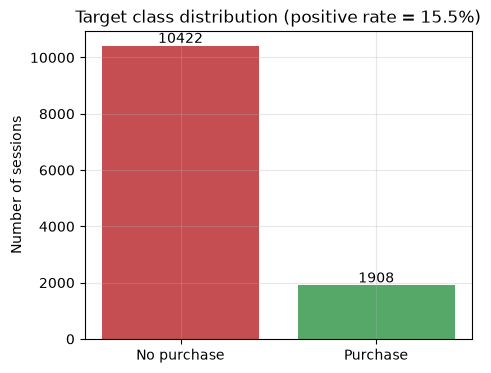

In [5]:
counts = df["Revenue"].value_counts().sort_index()
positive_rate = df["Revenue"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["No purchase", "Purchase"],
    [counts[False], counts[True]],
    color=[COLOR_NEGATIVE, COLOR_POSITIVE],
)
for i, v in enumerate([counts[False], counts[True]]):
    ax.text(i, v + 100, str(v), ha="center")
ax.set_title(f"Target class distribution (positive rate = {positive_rate:.1%})")
ax.set_ylabel("Number of sessions")
save_fig(fig, "target_distribution.png")
plt.show()


**Interpretation:** ~15.5% of sessions convert. A model that always predicts
"no purchase" would already be ~84.5% accurate while being operationally
useless -- confirming that PR-AUC and an explicit cost-based threshold
(Section 16) are the right tools here, not accuracy.


## 5. Numerical-Feature Distributions

Distributions of the core numeric engagement features (log1p-scaled on the
x-axis where heavily skewed, for readability only -- models use the raw,
properly scaled values via the preprocessing pipeline in Section 9).


Saved figure: docs/figures/numeric_distributions.png


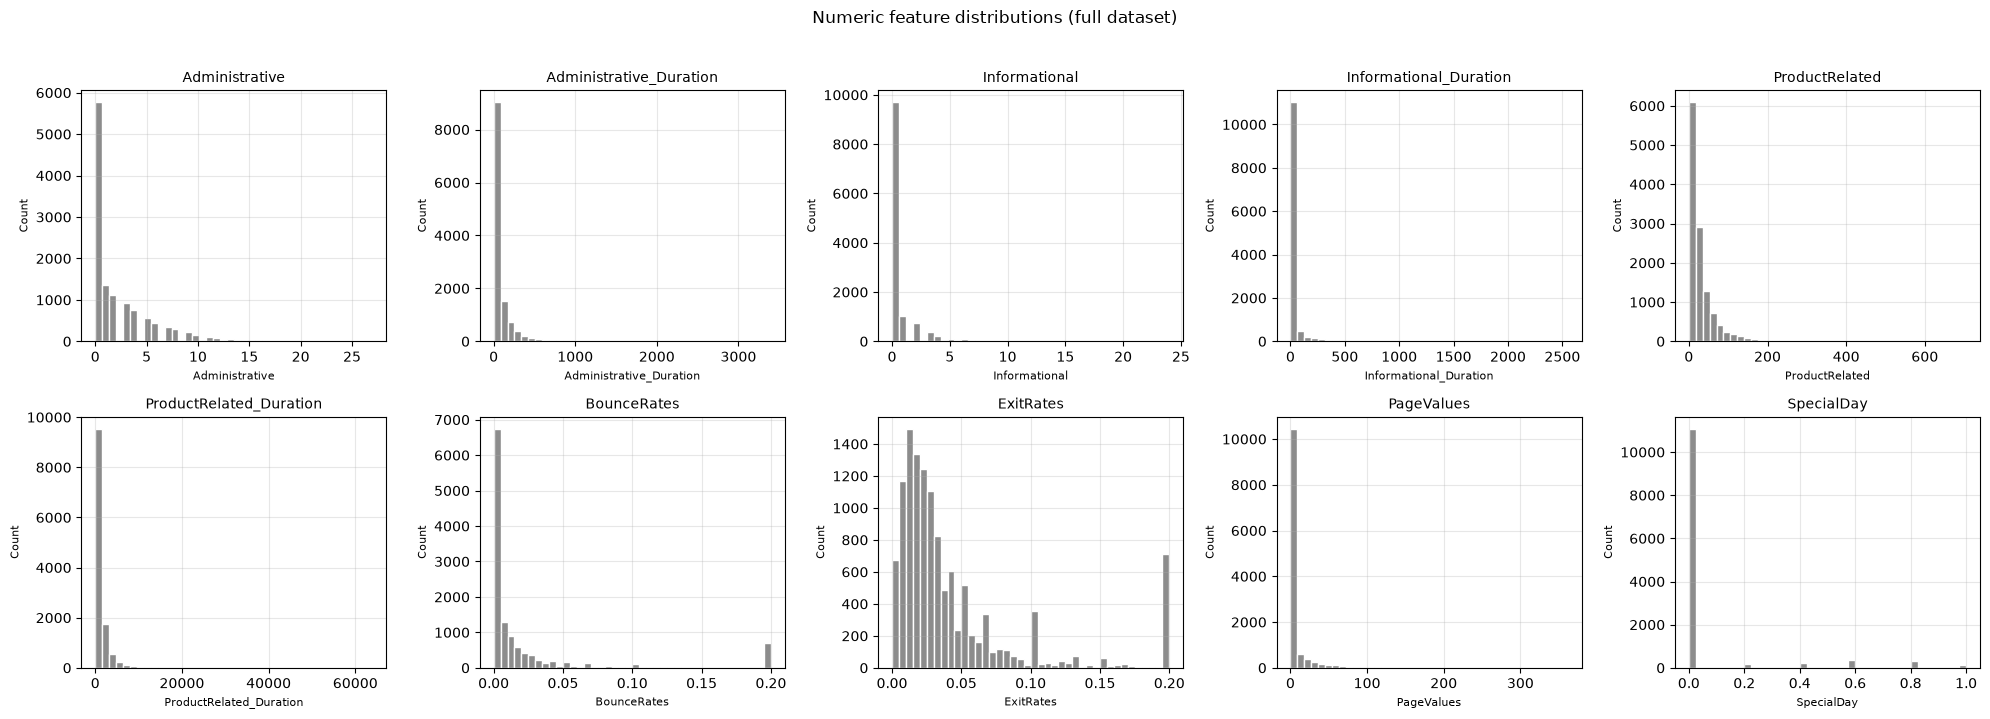

In [6]:
numeric_cols = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), numeric_cols, strict=True):
    values = df[col]
    ax.hist(values, bins=40, color=COLOR_NEUTRAL, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
fig.suptitle("Numeric feature distributions (full dataset)", y=1.02)
fig.tight_layout()
save_fig(fig, "numeric_distributions.png")
plt.show()


**Interpretation:** most engagement features (page counts/durations,
`PageValues`) are heavily right-skewed -- a small number of highly engaged
sessions dominate the upper range. `BounceRates`/`ExitRates` are bounded in
[0, 1] and concentrated near zero. `SpecialDay` is a discretized proximity
score, not continuous.


## 6. Categorical Conversion-Rate Comparisons

Conversion rate (share of sessions with `Revenue = True`) by category, for
the categorical features most relevant to the decision layer downstream.


Saved figure: docs/figures/categorical_conversion_rates.png


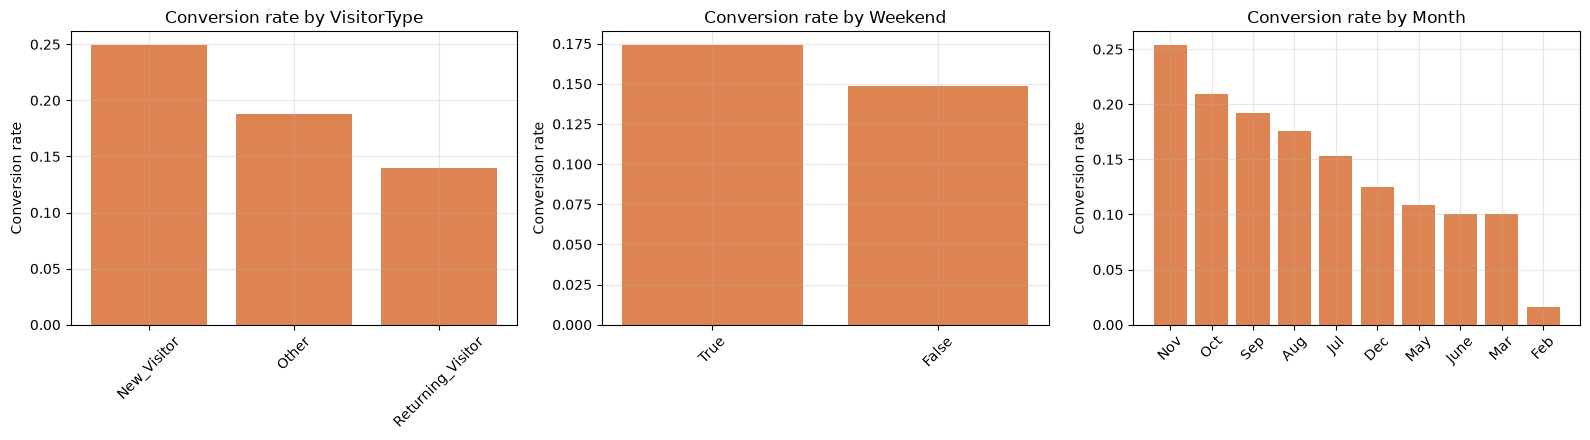

In [7]:
cat_cols = ["VisitorType", "Weekend", "Month"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, cat_cols, strict=True):
    rates = df.groupby(col, observed=True)["Revenue"].mean().sort_values(ascending=False)
    ax.bar(rates.index.astype(str), rates.values, color=COLOR_MLP)
    ax.set_title(f"Conversion rate by {col}")
    ax.set_ylabel("Conversion rate")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
save_fig(fig, "categorical_conversion_rates.png")
plt.show()


**Interpretation:** new visitors convert at a notably higher rate than
returning visitors (novelty/intent effect), weekend sessions convert
slightly more than weekday sessions, and conversion rate varies substantially
by month (highest around November, lowest in February) -- plausible seasonal
effects, though the dataset has no real timestamp, only a categorical month
(a stated limitation, Section 20).


## 7. `PageValues` Leakage Decision

`PageValues` is the single most predictive raw feature in this dataset --
and that is exactly why it is excluded from the deployment-safe feature set.
Per the source documentation, `PageValues` is computed from the average
value of a page relative to transactions completed *after* viewing it: it is
constructed from downstream conversion outcomes, not observable independently
at decision time. Full review: `docs/leakage-audit.md`.


In [8]:
contract = load_json("artifacts/metadata/feature_contract.json")
print(f"feature_contract_version: {contract['feature_contract_version']}")
print(f"Deployment-safe features ({len(contract['deployment_safe_features'])}):")
print([f["name"] for f in contract["deployment_safe_features"]])
print()
print("Excluded:")
for f in contract["excluded_features"]:
    print(f"  {f['name']}: {f['reason']} -- {f['explanation'][:140]}...")


feature_contract_version: 1.0.0
Deployment-safe features (16):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Excluded:
  PageValues: LEAKAGE_RISK -- PageValues is computed by the analytics source from the average value of pages visited prior to completing a transaction, making it derived ...


Saved figure: docs/figures/pagevalues_leakage_illustration.png


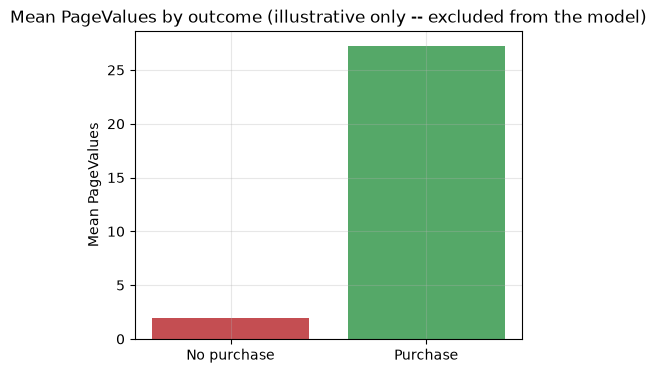

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
means = df.groupby("Revenue")["PageValues"].mean()
ax.bar(
    ["No purchase", "Purchase"],
    [means[False], means[True]],
    color=[COLOR_NEGATIVE, COLOR_POSITIVE],
)
ax.set_title("Mean PageValues by outcome (illustrative only -- excluded from the model)")
ax.set_ylabel("Mean PageValues")
save_fig(fig, "pagevalues_leakage_illustration.png")
plt.show()


**Interpretation:** the enormous gap in mean `PageValues` between converting
and non-converting sessions is precisely the leakage signature described
above -- it is a symptom of the target, not an independent predictor. It is
excluded from the deployment-safe model (16 features), and every model
trained in this notebook uses only the deployment-safe set.


## 8. Group-Aware Train/Validation/Test Split Verification

The 70/15/15 stratified split (`conversion_router.data.split`) groups rows by
a deterministic fingerprint over the 16 deployment-safe features before
splitting, so that rows sharing identical deployment-safe feature values
cannot end up in different partitions (decision D07). Verified below on the
frozen split.


In [10]:
split_summary = load_json("artifacts/metadata/split_summary.json")
for part in split_summary["splits"]:
    print(
        f"{part['name']:>10}: {part['n_rows']:>5} rows "
        f"({part['fraction_of_total']:.1%}), positive_rate={part['positive_rate']:.4f}"
    )

dup = split_summary["duplicate_leakage_check"]
print()
print(f"Duplicate fingerprint groups: {dup['n_duplicate_fingerprint_groups']} "
      f"({dup['n_duplicate_extra_rows']} extra rows)")
print(f"Conflicting-label groups: {dup['n_conflicting_label_groups']}")
print(f"Cross-split fingerprint groups: {dup['n_cross_split_fingerprint_groups']}")

assert dup["n_conflicting_label_groups"] == 0, "Unexpected label conflict in a duplicate group"
assert dup["n_cross_split_fingerprint_groups"] == 0, "A fingerprint group crossed a split boundary"
print()
print("Verified: no fingerprint group crosses a train/validation/test boundary.")


     train:  8635 rows (70.0%), positive_rate=0.1547
validation:  1850 rows (15.0%), positive_rate=0.1546
      test:  1845 rows (15.0%), positive_rate=0.1550

Duplicate fingerprint groups: 76 (125 extra rows)
Conflicting-label groups: 0
Cross-split fingerprint groups: 0

Verified: no fingerprint group crosses a train/validation/test boundary.


**Interpretation:** the split preserves both the ~70/15/15 row-count ratio
and the ~15.5% positive rate in every partition, and -- more importantly --
guarantees zero duplicate-feature leakage across partitions, which a naive
row-index split did not (see `DECISIONS.md` D07).


## 9. Train-Only Preprocessing Explanation

Numeric features are standardized, `Weekend` is cast to 0/1, and categorical
features are one-hot encoded with `handle_unknown="ignore"` (unseen
categories at inference time map to an all-zero vector rather than raising).
The pipeline (`conversion_router.data.preprocess`) is fit on the training
partition only and reused, unmodified, for validation, test, and the MLP.


In [11]:
from conversion_router.data.preprocess import get_output_feature_names, load_preprocessor

preprocessor = load_preprocessor()
feature_names = get_output_feature_names(preprocessor)
print(f"Preprocessor output dimensionality: {len(feature_names)}")
print(f"First 10 output feature names: {feature_names[:10]}")


Preprocessor output dimensionality: 71
First 10 output feature names: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend']


## 10. Logistic Regression Baseline

A class-weighted logistic regression trained on the same frozen split and
feature contract, used as the comparison point for the MLP. Full report:
`docs/baseline-report.md`.


In [12]:
baseline_metadata = load_json("artifacts/metadata/baseline_metadata.json")
print("sklearn_params:", baseline_metadata["sklearn_params"])
print("threshold_selection:", json.dumps(baseline_metadata["threshold_selection"], indent=2))


sklearn_params: {'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 42}
threshold_selection: {
  "method": "business_cost_grid_search_on_validation_only",
  "threshold": 0.47,
  "false_negative_cost": 5.0,
  "false_positive_cost": 1.0,
  "cost_rationale": "A missed converting session (false negative) is assumed 5x costlier than an unnecessary manual review (false positive): a lost potential sale outweighs one extra review. This is a stated modeling assumption, not a measured business figure.",
  "expected_cost_at_threshold": 914.0,
  "n_false_negatives": 54,
  "n_false_positives": 644,
  "n_true_positives": 232,
  "n_true_negatives": 920,
  "n_validation_rows": 1850,
  "selected_on": "validation_only"
}


## 11. PyTorch MLP Architecture and Training Configuration

A tabular MLP (`conversion_router.modeling.network.ConversionMLP`):
input &rarr; 128 &rarr; 64 &rarr; 32 &rarr; 1 logit, ReLU activations,
dropout 0.3, trained with `BCEWithLogitsLoss` using a `pos_weight` computed
from the training split's class imbalance, Adam optimizer, and early
stopping on validation PR-AUC.


In [13]:
from conversion_router.modeling.train import load_checkpoint

mlp_model = load_checkpoint()
print(mlp_model)
print()
n_params = sum(p.numel() for p in mlp_model.parameters())
print(f"Total trainable parameters: {n_params:,}")


ConversionMLP(
  (network): Sequential(
    (0): Linear(in_features=71, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 19,585


In [14]:
mlp_metadata = load_json("artifacts/metadata/mlp_metadata.json")
print(json.dumps(mlp_metadata["training_configuration"], indent=2))


{
  "hidden_sizes": [
    128,
    64,
    32
  ],
  "dropout": 0.3,
  "learning_rate": 0.001,
  "batch_size": 64,
  "max_epochs": 100,
  "patience": 10,
  "best_epoch": 5,
  "n_epochs_run": 15,
  "best_val_pr_auc_raw": 0.356
}


## 12. Training/Validation Loss and PR-AUC Curves


Saved figure: docs/figures/mlp_training_curves.png


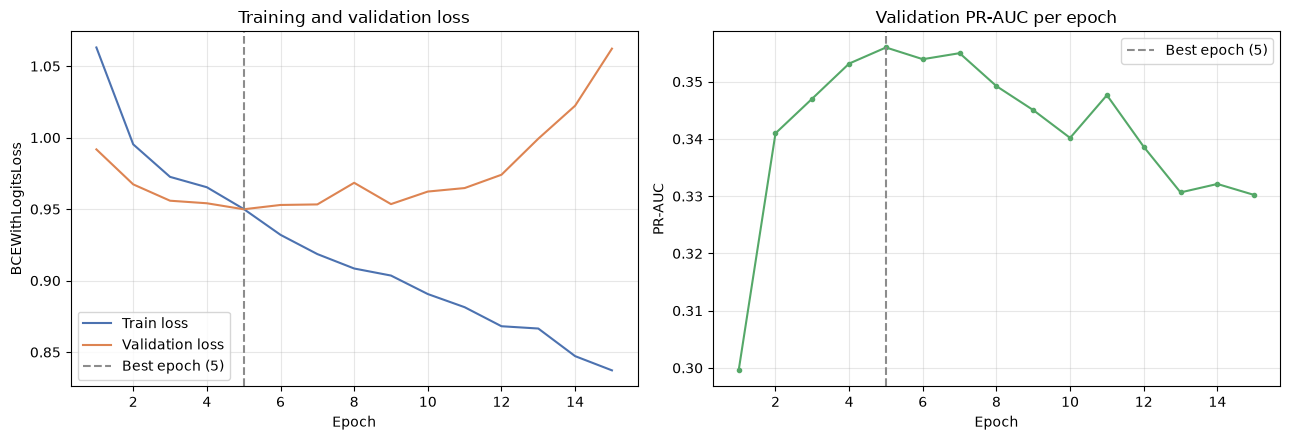

In [15]:
history = load_json("artifacts/metadata/mlp_training_history.json")
epochs_df = pd.DataFrame(history["epochs"])
best_epoch = history["best_epoch"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_df["epoch"], epochs_df["train_loss"], label="Train loss", color=COLOR_BASELINE)
axes[0].plot(epochs_df["epoch"], epochs_df["val_loss"], label="Validation loss", color=COLOR_MLP)
axes[0].axvline(best_epoch, color=COLOR_NEUTRAL, linestyle="--", label=f"Best epoch ({best_epoch})")
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCEWithLogitsLoss")
axes[0].legend()

axes[1].plot(
    epochs_df["epoch"], epochs_df["val_pr_auc"], color=COLOR_POSITIVE, marker="o", markersize=3
)
axes[1].axvline(
    best_epoch, color=COLOR_NEUTRAL, linestyle="--", label=f"Best epoch ({best_epoch})"
)
axes[1].set_title("Validation PR-AUC per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()

fig.tight_layout()
save_fig(fig, "mlp_training_curves.png")
plt.show()


**Interpretation:** validation PR-AUC peaks early (epoch 5) and early
stopping halts training shortly after, avoiding overfitting on this
relatively small, noisy dataset -- consistent with the blueprint's guidance
to prefer small, justified configurations over extensive tuning.


## 13. Baseline-versus-MLP Metric Comparison (Frozen Test Set)

The numbers below come directly from `artifacts/metadata/test_evaluation.json`,
produced once by `scripts/evaluate_test.py`. This notebook does not
recompute them from the test set -- it only visualizes the frozen result.


In [16]:
test_eval = load_json("artifacts/metadata/test_evaluation.json")
baseline_metrics = test_eval["baseline"]["metrics"]
mlp_metrics = test_eval["mlp"]["metrics"]

metric_keys = ("pr_auc", "roc_auc", "precision", "recall", "f1")
comparison = pd.DataFrame(
    {
        "Baseline (LogReg)": [baseline_metrics[k] for k in metric_keys],
        "MLP (calibrated)": [mlp_metrics[k] for k in metric_keys],
    },
    index=["PR-AUC", "ROC-AUC", "Precision", "Recall", "F1"],
)
comparison


,Baseline (LogReg),MLP (calibrated)
PR-AUC,0.3020,0.3160
ROC-AUC,0.7433,0.7543
Precision,0.2506,0.2514
Recall,0.7832,0.7797
F1,0.3797,0.3802


Saved figure: docs/figures/baseline_vs_mlp_metrics.png


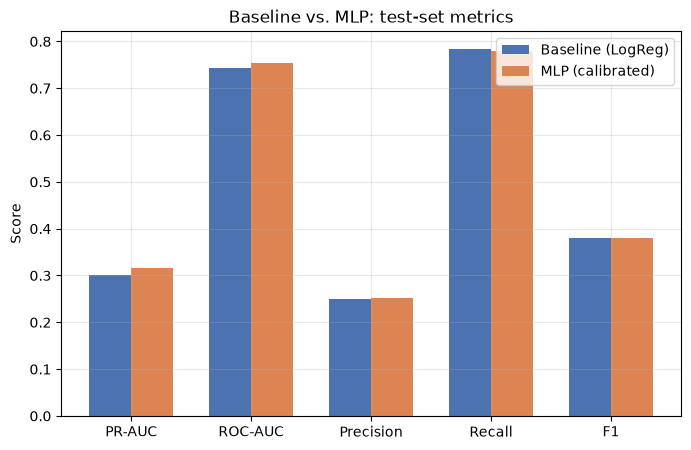

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison.index))
width = 0.35
ax.bar(
    x - width / 2, comparison["Baseline (LogReg)"], width,
    label="Baseline (LogReg)", color=COLOR_BASELINE,
)
ax.bar(
    x + width / 2, comparison["MLP (calibrated)"], width,
    label="MLP (calibrated)", color=COLOR_MLP,
)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.set_ylabel("Score")
ax.set_title("Baseline vs. MLP: test-set metrics")
ax.legend()
save_fig(fig, "baseline_vs_mlp_metrics.png")
plt.show()


**Interpretation:** the MLP modestly outperforms the logistic regression
baseline on PR-AUC (the primary metric) and ROC-AUC, with precision/recall/F1
close to the baseline's. This is an honest result: the improvement is real
but small, which is expected on a dataset of this size and structure -- the
value of the deep learning model here is incremental, not transformative,
and the notebook does not overstate it.


## 14. Precision-Recall and ROC Curves (Test Set)


Saved figure: docs/figures/pr_roc_curves.png


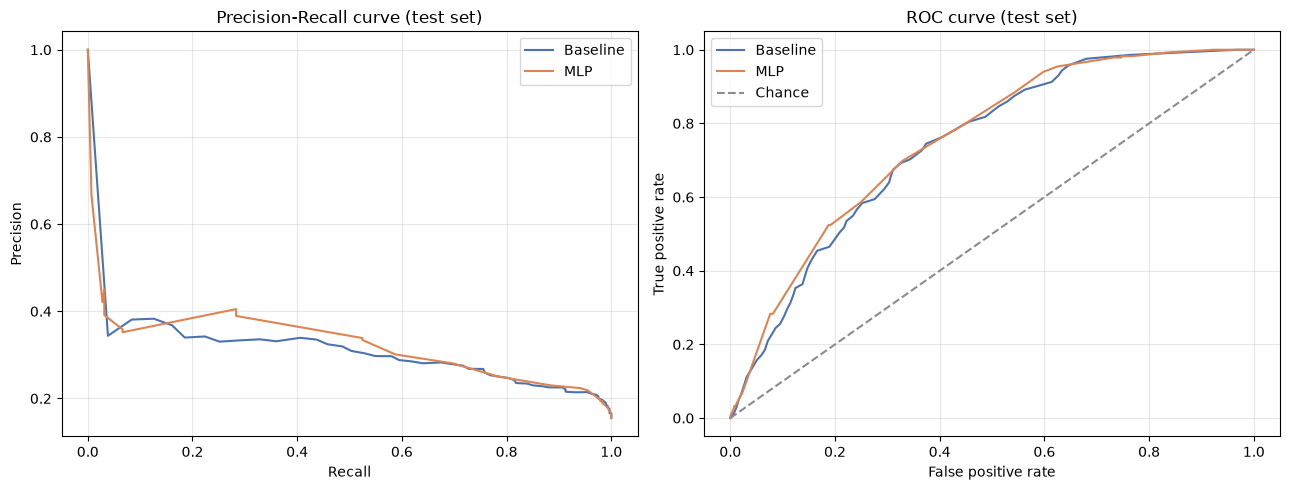

In [18]:
b_curves = test_eval["baseline"]["curves"]
m_curves = test_eval["mlp"]["curves"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(b_curves["precision_recall"]["recall"], b_curves["precision_recall"]["precision"],
             color=COLOR_BASELINE, label="Baseline")
axes[0].plot(m_curves["precision_recall"]["recall"], m_curves["precision_recall"]["precision"],
             color=COLOR_MLP, label="MLP")
axes[0].set_title("Precision-Recall curve (test set)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()

axes[1].plot(b_curves["roc"]["fpr"], b_curves["roc"]["tpr"], color=COLOR_BASELINE, label="Baseline")
axes[1].plot(m_curves["roc"]["fpr"], m_curves["roc"]["tpr"], color=COLOR_MLP, label="MLP")
axes[1].plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle="--", label="Chance")
axes[1].set_title("ROC curve (test set)")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()

fig.tight_layout()
save_fig(fig, "pr_roc_curves.png")
plt.show()


**Interpretation:** the MLP's curve sits at or slightly above the baseline's
across most of the operating range, consistent with the modest PR-AUC/ROC-AUC
improvement in Section 13 -- neither model dominates the other everywhere,
but the MLP is the more consistent choice on this split.


## 15. Calibration Curve and Brier Score (MLP, Test Set)

Raw MLP sigmoid output is not treated as "confidence" (blueprint Section
5.5); it is calibrated with isotonic regression fit on validation data only,
then applied here to the test set for evaluation.


Saved figure: docs/figures/calibration_curve.png


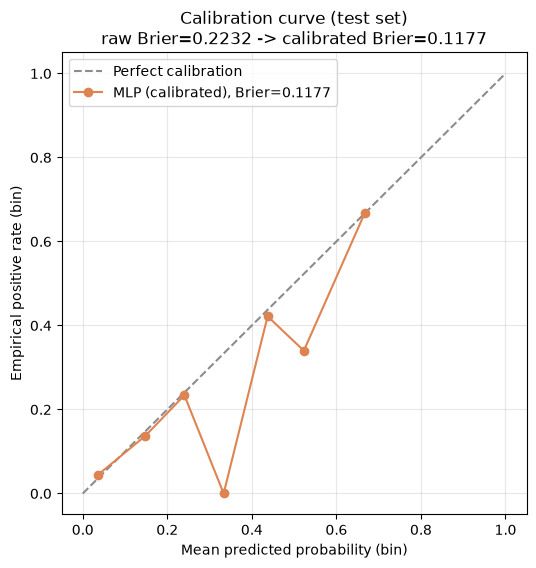

In [19]:
bins = pd.DataFrame(test_eval["mlp"]["calibration_bins"])
brier_raw = test_eval["mlp"]["brier_score_raw"]
brier_cal = test_eval["mlp"]["brier_score_calibrated"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle="--", label="Perfect calibration")
ax.plot(bins["mean_predicted"], bins["empirical_rate"], marker="o", color=COLOR_MLP,
        label=f"MLP (calibrated), Brier={brier_cal:.4f}")
title = (
    f"Calibration curve (test set)\n"
    f"raw Brier={brier_raw:.4f} -> calibrated Brier={brier_cal:.4f}"
)
ax.set_title(title)
ax.set_xlabel("Mean predicted probability (bin)")
ax.set_ylabel("Empirical positive rate (bin)")
ax.legend()
save_fig(fig, "calibration_curve.png")
plt.show()


**Interpretation:** calibrated probabilities track the diagonal closely on
test data too (not just validation, where the calibrator was fit), and the
Brier score improves substantially versus the raw sigmoid output -- the
calibration generalizes, it is not an artifact of the validation fit.


## 16. Validation Threshold/Cost Trade-off

The decision threshold for each model was selected on **validation data
only** (never test), minimizing an explicit business cost: a missed
conversion (false negative) is assumed 5x costlier than one unnecessary
manual review (false positive). This section re-visualizes that already-made
decision using the frozen validation prediction files -- it does not
re-select anything.


Saved figure: docs/figures/threshold_cost_tradeoff.png


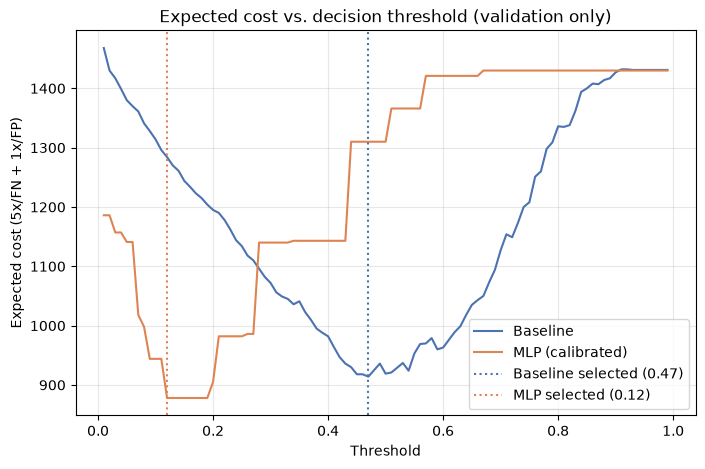

In [20]:
from conversion_router.modeling.threshold import (
    FALSE_NEGATIVE_COST,
    FALSE_POSITIVE_COST,
    THRESHOLD_GRID,
)

val_dir = PROJECT_ROOT / "data" / "processed"
baseline_val = pd.read_csv(val_dir / "baseline_validation_predictions.csv")
mlp_val = pd.read_csv(val_dir / "mlp_validation_predictions.csv")


def cost_curve(y_true, y_proba):
    costs = []
    for t in THRESHOLD_GRID:
        y_pred = y_proba >= t
        fn = int(((y_true == 1) & (~y_pred)).sum())
        fp = int(((y_true == 0) & (y_pred)).sum())
        costs.append(FALSE_NEGATIVE_COST * fn + FALSE_POSITIVE_COST * fp)
    return np.array(costs)


baseline_costs = cost_curve(
    baseline_val["y_true"].to_numpy(), baseline_val["y_pred_proba"].to_numpy()
)
mlp_costs = cost_curve(mlp_val["y_true"].to_numpy(), mlp_val["calibrated_proba"].to_numpy())

baseline_t = baseline_metadata["threshold_selection"]["threshold"]
mlp_t = mlp_metadata["threshold_selection"]["threshold"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(THRESHOLD_GRID, baseline_costs, color=COLOR_BASELINE, label="Baseline")
ax.plot(THRESHOLD_GRID, mlp_costs, color=COLOR_MLP, label="MLP (calibrated)")
ax.axvline(
    baseline_t, color=COLOR_BASELINE, linestyle=":", label=f"Baseline selected ({baseline_t})"
)
ax.axvline(mlp_t, color=COLOR_MLP, linestyle=":", label=f"MLP selected ({mlp_t})")
ax.set_title("Expected cost vs. decision threshold (validation only)")
ax.set_xlabel("Threshold")
ax.set_ylabel(f"Expected cost ({FALSE_NEGATIVE_COST:.0f}x/FN + {FALSE_POSITIVE_COST:.0f}x/FP)")
ax.legend()
save_fig(fig, "threshold_cost_tradeoff.png")
plt.show()


**Interpretation:** both cost curves are minimized at a relatively low
threshold, reflecting the 5:1 false-negative-to-false-positive cost
assumption -- the policy would rather over-flag sessions for review than
miss a likely conversion. The MLP's calibrated probability space shifts its
optimal threshold lower than the baseline's; this is expected given isotonic
calibration reshapes the probability distribution and is not itself a
finding about the model's discriminative quality (that is PR-AUC/ROC-AUC,
Section 13).


## 17. Test Confusion Matrices


Saved figure: docs/figures/test_confusion_matrices.png


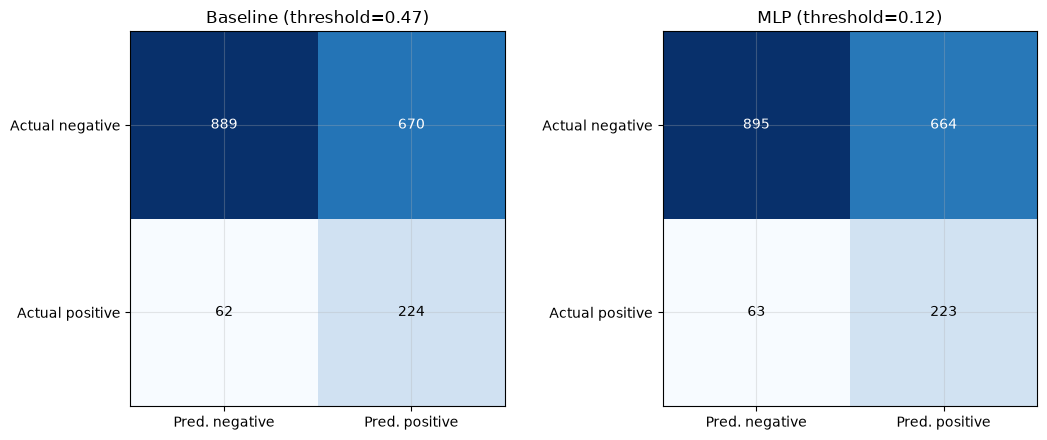

In [21]:
model_names = ["Baseline", "MLP"]
model_metrics = [baseline_metrics, mlp_metrics]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name, metrics in zip(axes, model_names, model_metrics, strict=True):
    cm = metrics["confusion_matrix"]
    matrix = np.array(
        [[cm["true_negative"], cm["false_positive"]], [cm["false_negative"], cm["true_positive"]]]
    )
    ax.imshow(matrix, cmap="Blues")
    for i in range(2):
        for j in range(2):
            color = "white" if matrix[i, j] > matrix.max() / 2 else "black"
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color=color)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred. negative", "Pred. positive"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Actual negative", "Actual positive"])
    ax.set_title(f"{name} (threshold={metrics['threshold']})")
fig.tight_layout()
save_fig(fig, "test_confusion_matrices.png")
plt.show()


**Interpretation:** both models produce a similar shape of error -- many
false positives (a deliberate consequence of the 5:1 cost assumption
favoring recall) and relatively few false negatives. The MLP catches a
comparable number of true positives with a marginally different trade-off.


## 18. False-Positive and False-Negative Analysis (MLP, Test Set)

Representative examples, taken directly from the frozen
`test_evaluation.json` (`error_examples`), not recomputed here.


In [22]:
fn_examples = pd.DataFrame(test_eval["error_examples"]["false_negatives"])
print("False negatives (missed conversions) -- highest calibrated probability among misses:")
fn_examples


False negatives (missed conversions) -- highest calibrated probability among misses:


,row_index,y_true,mlp_calibrated_proba,mlp_uncertain,VisitorType,Month,Weekend,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates
0,76,1,0.1111,True,Returning_Visitor,Feb,False,36,2111.341667,0.004348,0.014493
1,7321,1,0.1111,True,Returning_Visitor,June,False,237,9437.769068,0.010204,0.030381
2,5626,1,0.1111,True,New_Visitor,Oct,False,3,275.000000,0.000000,0.050000


In [23]:
fp_examples = pd.DataFrame(test_eval["error_examples"]["false_positives"])
print("False positives (unnecessary reviews) -- highest calibrated probability among wrong calls:")
fp_examples


False positives (unnecessary reviews) -- highest calibrated probability among wrong calls:


,row_index,y_true,mlp_calibrated_proba,mlp_uncertain,VisitorType,Month,Weekend,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates
0,8438,0,0.6667,False,Returning_Visitor,Nov,False,340,10902.45826,0.001713,0.015735
1,11056,0,0.5652,False,Returning_Visitor,Nov,False,315,11232.65691,0.003165,0.019253
2,11096,0,0.5652,False,Returning_Visitor,Nov,True,231,11246.13379,0.001747,0.010029


**Interpretation:** the false negatives sit right at the decision boundary
(calibrated probability close to the threshold) and are flagged
`mlp_uncertain=True` -- exactly the behavior the uncertainty rule is meant to
produce, routing borderline misses toward human review rather than silently
dropping them. The false positives are highly engaged sessions (long
duration, many product pages) that plausibly looked like strong conversion
candidates but did not convert -- a believable, explainable failure mode
rather than a random one.


## 19. Segment Analysis by VisitorType, Month, and TrafficType (Test Set)


Saved figure: docs/figures/segment_analysis.png


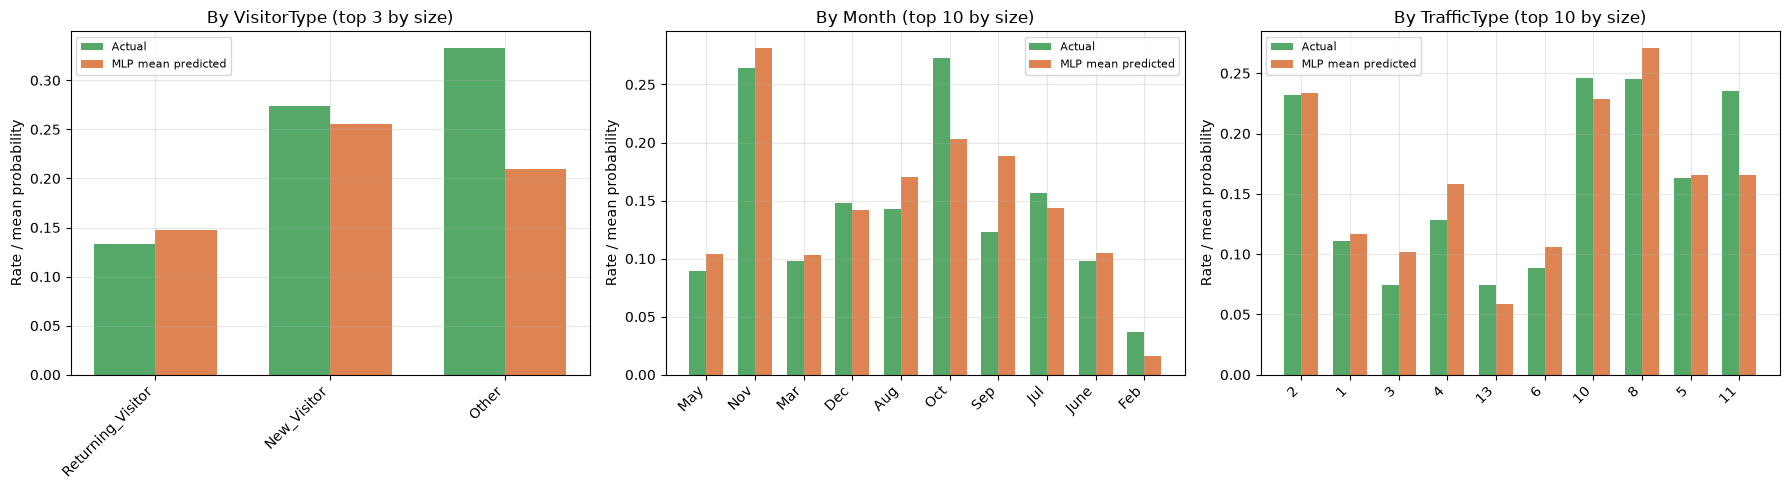

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["VisitorType", "Month", "TrafficType"], strict=True):
    seg = pd.DataFrame(test_eval["segment_analysis"][col])
    seg = seg.sort_values("n_sessions", ascending=False).head(10)
    x = np.arange(len(seg))
    width = 0.35
    ax.bar(x - width / 2, seg["actual_positive_rate"], width, label="Actual", color=COLOR_POSITIVE)
    ax.bar(
        x + width / 2, seg["mean_mlp_calibrated_proba"], width,
        label="MLP mean predicted", color=COLOR_MLP,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(seg["segment"], rotation=45, ha="right")
    ax.set_title(f"By {col} (top {len(seg)} by size)")
    ax.set_ylabel("Rate / mean probability")
    ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "segment_analysis.png")
plt.show()


**Interpretation:** the MLP's mean predicted probability tracks the actual
conversion rate reasonably well across visitor types, months, and traffic
types -- there is no segment where the model is severely and systematically
over- or under-confident, though smaller segments (e.g. rare `TrafficType`
codes) naturally show noisier estimates given their small sample sizes.


## 20. Limitations and Conclusions

**Limitations.**

- **Single dataset, single source.** All results are specific to this UCI
  dataset; no external validation set exists to confirm generalization to a
  different store, season, or user base.
- **No real timestamp.** `Month` is categorical; a genuine temporal holdout
  (train on earlier time, test on later time) was not possible, so any
  seasonal effect the model has learned is a within-sample pattern, not a
  validated forecast.
- **Anonymized technical/context codes.** `OperatingSystems`, `Browser`,
  `Region`, and especially `TrafficType` are opaque integer codes with no
  documented real-world mapping; per decision D06, this project does not
  interpret `TrafficType` as measuring platform dependence.
- **Modest deep-learning improvement.** The MLP's PR-AUC/ROC-AUC gain over
  the logistic regression baseline is real but small; on a dataset of this
  size and structure, a simple, interpretable baseline is already
  competitive, and that is reported honestly rather than overstated.
- **Threshold sensitivity.** Both the baseline's and the MLP's decision
  thresholds depend on an assumed 5:1 false-negative-to-false-positive cost
  ratio, which is a stated modeling assumption, not a measured business
  figure; a different ratio would shift both thresholds and the resulting
  precision/recall trade-off materially.
- **Class imbalance.** With ~15.5% positives, all reported metrics --
  especially precision at a low threshold -- should be read in that context,
  not compared naively to a balanced-class benchmark.

**Conclusions.**

1. Traffic volume and conversion quality are genuinely separable in this
   data: engagement depth, bounce/exit rates, and visitor type carry real,
   leakage-safe signal (Sections 5-7), distinct from `PageValues`, which is
   excluded because it leaks the outcome it is meant to predict.
2. A group-aware split is necessary, not optional, for this dataset: 76
   duplicate-feature groups would otherwise leak across train/validation/test
   boundaries (Section 8).
3. The PyTorch MLP modestly but consistently outperforms the logistic
   regression baseline on the primary metric (PR-AUC) and calibrates
   substantially better than its own raw output after isotonic calibration
   (Section 15) -- calibration matters more here than architecture choice.
4. The resulting system's errors are explainable, not arbitrary (Section 18),
   and the deterministic uncertainty rule correctly flags the borderline
   cases where the system should defer to a human reviewer rather than act
   automatically -- which is the operational goal stated in Section 1.


## 21. Validation-Only Hyperparameter Sensitivity

A bounded, preregistered sensitivity study compared five training
configurations across three seeds (15 total runs) using only the
train/validation splits. The test set was never accessed. No candidate
checkpoints were saved; no model was promoted. Full report:
[`docs/hyperparameter-sensitivity.md`](../docs/hyperparameter-sensitivity.md).

This section reads the precomputed results from
`docs/hyperparameter_sensitivity_results.json` -- it does not rerun the
study.

In [25]:
sensitivity = load_json("docs/hyperparameter_sensitivity_results.json")

# Aggregate results table
agg = sensitivity["aggregate_results"]
agg_df = pd.DataFrame(
    {
        name: {
            "Mean PR-AUC": vals["mean_val_pr_auc"],
            "Std PR-AUC": vals["std_val_pr_auc"],
            "Mean ROC-AUC": vals["mean_val_roc_auc"],
            "Mean Brier": vals["mean_val_brier_raw"],
        }
        for name, vals in agg.items()
    }
).T.sort_values("Mean PR-AUC", ascending=False)

print("Configuration ranking by mean validation PR-AUC:")
print(agg_df.to_string())
print()

outcome = sensitivity["candidate_outcome"]
print(f"Candidate outcome: {outcome['note']}")
print(f"V1 remains authoritative: {outcome['v1_authoritative']}")
print(f"Promoted: {outcome['promoted']}")

Configuration ranking by mean validation PR-AUC:
                     Mean PR-AUC  Std PR-AUC  Mean ROC-AUC  Mean Brier
larger_batch              0.3611      0.0082        0.7741      0.1978
lower_learning_rate       0.3595      0.0008        0.7720      0.1890
v1_reference              0.3563      0.0031        0.7702      0.2026
compact_network           0.3561      0.0040        0.7708      0.1963
lower_dropout             0.3552      0.0068        0.7705      0.2071

Candidate outcome: No robust validation-only candidate met the preregistered threshold.
V1 remains authoritative: True
Promoted: False
